In [19]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sb
import plotly.express as px
df = pd.read_csv('ToyotaCorolla.csv')
df.shape

(1436, 39)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

In [21]:
df.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [53]:
trash = ['Cylinders', 'Id']
for col in df.select_dtypes('number').columns:
    
    if df[col].min() ==0 and df[col].max() == 1:
        trash.append(col)
    else: 
        print(f"{col}: [{df[col].min():.2f}, {df[col].max():.2f}]")

Id: [1.00, 1442.00]
Price: [4350.00, 32500.00]
Age_08_04: [1.00, 80.00]
Mfg_Month: [1.00, 12.00]
Mfg_Year: [1998.00, 2004.00]
KM: [1.00, 243000.00]
HP: [69.00, 192.00]
CC: [1300.00, 16000.00]
Doors: [2.00, 5.00]
Cylinders: [4.00, 4.00]
Gears: [3.00, 6.00]
Quarterly_Tax: [19.00, 283.00]
Weight: [1000.00, 1615.00]
Guarantee_Period: [3.00, 36.00]


<Axes: >

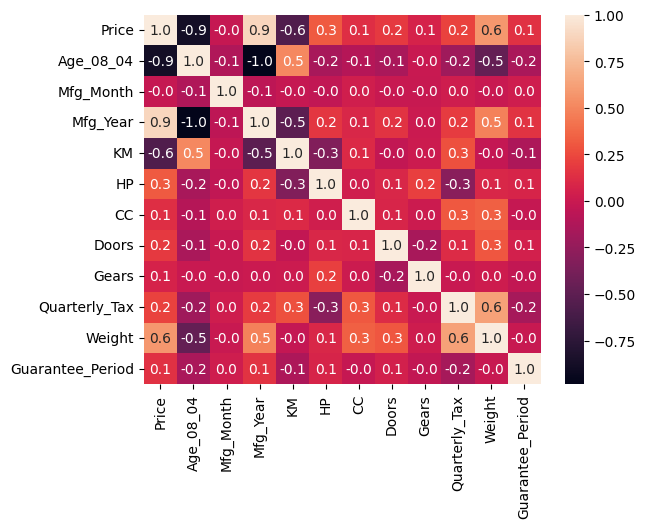

In [51]:
df_for_corr = df.select_dtypes('number').drop(columns=trash)
sb.heatmap(df_for_corr.corr(),annot=True,fmt=".1f")

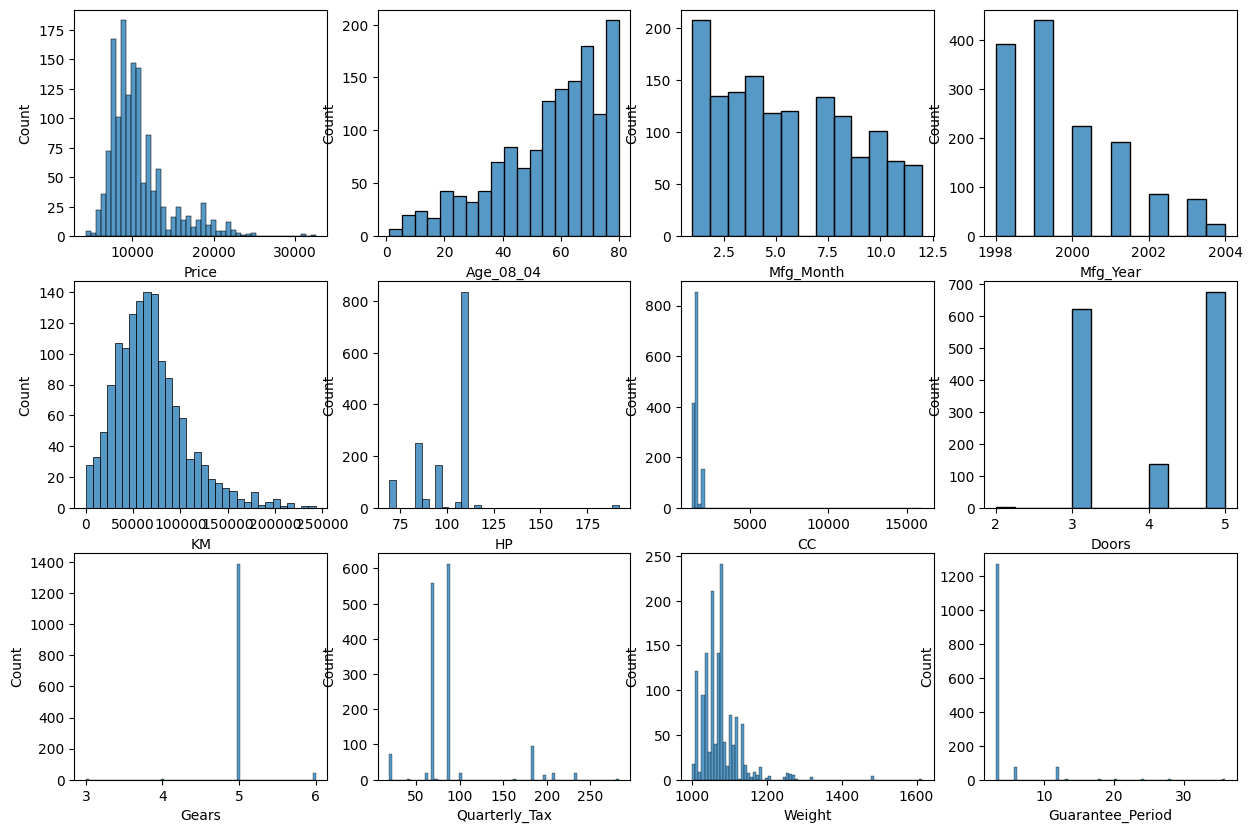

In [54]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))

for i, el in enumerate(df_for_corr.columns.array):
    sb.histplot(data=df_for_corr, x=el, ax=axes[i//4, i%4])

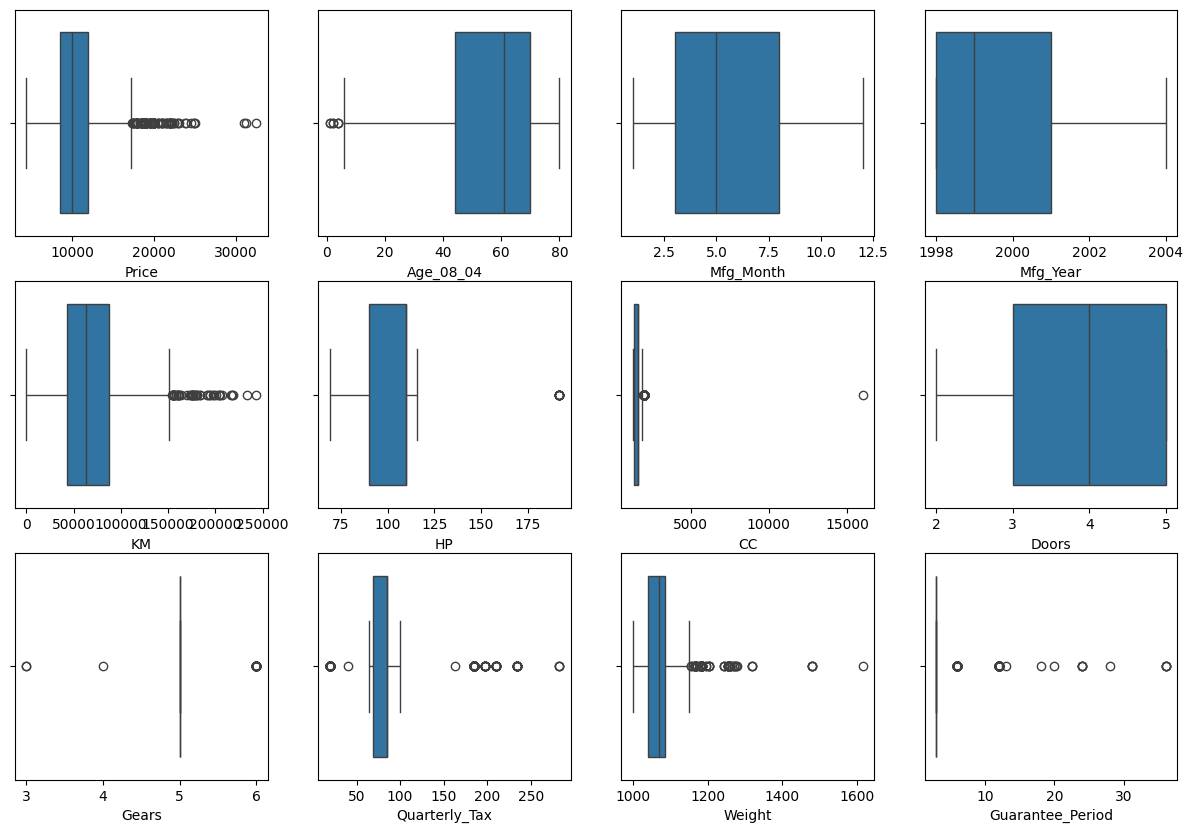

In [55]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))

for i, el in enumerate(df_for_corr.columns.array):
    sb.boxplot(data=df_for_corr, x=el, ax=axes[i//4, i%4])

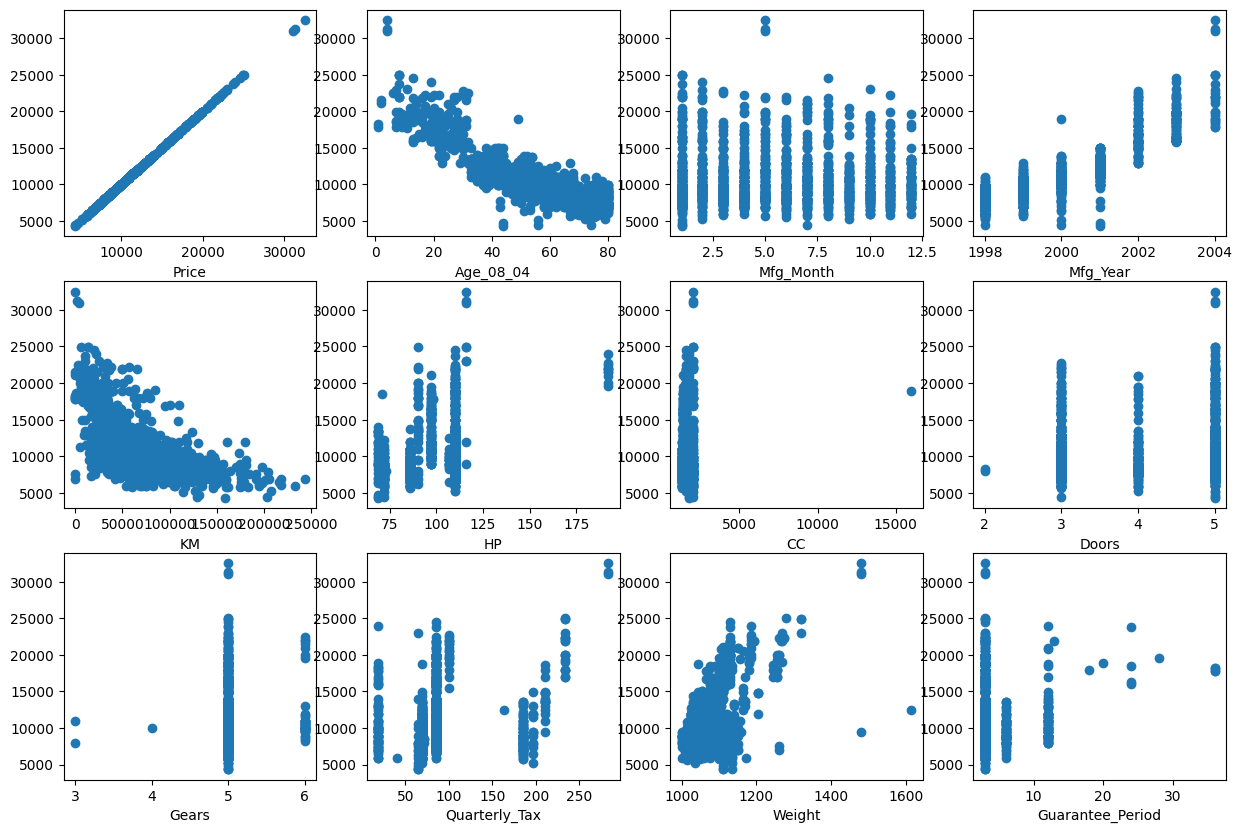

In [63]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))

for i, el in enumerate(df_for_corr.columns.array):
    axes[i//4, i%4].scatter(x=df_for_corr[el],y=df_for_corr['Price'])
    axes[i//4, i%4].set_xlabel(el)